# Random forests

### Hundreds of mediocre trees, voting

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why averaging many overfitted trees works, what the two sources of randomness each contribute, how to read feature importance without being misled, and why on this dataset the forest does **not** beat a straight line |
| **You should already know** | [Logistic regression](../../03-classification/01-logistic-regression/) |
| **Dataset** | UCI Dry Bean (13,611 × 16), the same one used in the logistic regression notebook |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [04-05 Gradient boosting](../05-gradient-boosting/) |

---

## 1. The idea

A single decision tree grown to full depth memorises its training data. It will
happily build a rule for one unusual bean and get it exactly right, and that
rule will be worthless on the next batch. Trees have **low bias and enormous
variance**: change a handful of training rows and you get a visibly different tree.

The random forest turns that weakness into the mechanism. Grow hundreds of
overfitted trees, each on a slightly different view of the data, and average
their votes. The individual mistakes are different from tree to tree, so they
cancel; the signal is the same in all of them, so it survives.

Two independent sources of randomness make the trees differ:

1. **Bootstrap sampling**: each tree sees a random sample of the rows, drawn
   with replacement, so about 37% of rows are missing from any given tree.
2. **Feature subsampling**: at every split, each tree may only consider a
   random handful of the columns, typically $\sqrt{n}$ of them.

The second one is what makes it a *random forest* rather than plain bagging, and
section 5 measures how much it is actually worth.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.dry_bean()
print(f"{X.shape[0]:,} beans, {X.shape[1]} measurements, {y.nunique()} varieties")
print(y.value_counts().to_string())

13,611 beans, 16 measurements, 7 varieties
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522


## 2. The maths, such as it is

There is no equation being solved here, but there is one that explains why it
works. For $B$ predictors each with variance $\sigma^2$ and pairwise correlation
$\rho$, the variance of their average is:

$$\operatorname{Var}(\bar{f}) = \rho\sigma^2 + \frac{1 - \rho}{B}\sigma^2$$

Read the two terms. The second shrinks to nothing as you add trees: this is why
more trees never hurt. The first does not shrink at all. **It is floored by how
correlated the trees are with each other.**

That single fact explains the whole design. Bootstrap sampling and feature
subsampling exist for one purpose: to push $\rho$ down. Without them all the
trees would be nearly identical, $\rho$ would be close to 1, and averaging would
buy you nothing.

## 3. From scratch

Bagging is short enough to write out. Trees themselves are covered in
[03-06](../../03-classification/06-decision-trees/), so this uses scikit-learn's
tree as the building block and implements the ensemble around it.

In [2]:
from collections import Counter

from sklearn.tree import DecisionTreeClassifier


class BaggedTreesScratch:
    """Bootstrap aggregation over decision trees, written out in full."""

    def __init__(self, n_trees=100, max_features=None, random_state=0):
        self.n_trees = n_trees
        self.max_features = max_features   # None = plain bagging, "sqrt" = random forest
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        rng = np.random.default_rng(self.random_state)
        self.trees_ = []

        for i in range(self.n_trees):
            # Draw n rows WITH replacement. Roughly 37% of the original rows are
            # left out of each draw, which is where the out-of-bag idea comes from.
            rows = rng.integers(0, len(X), len(X))
            tree = DecisionTreeClassifier(max_features=self.max_features,
                                          random_state=int(rng.integers(1 << 31)))
            self.trees_.append(tree.fit(X[rows], y[rows]))
        return self

    def predict(self, X):
        X = np.asarray(X)
        # One row per tree, one column per sample.
        votes = np.array([tree.predict(X) for tree in self.trees_])
        # Majority vote down each column. Counter rather than scipy.stats.mode,
        # because the bean labels are strings and mode dropped non-numeric
        # support in SciPy 1.11.
        return np.array([Counter(column).most_common(1)[0][0] for column in votes.T])


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, stratify=y, random_state=SEED)

single = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)
bagged = BaggedTreesScratch(n_trees=100, random_state=SEED).fit(X_train, y_train)
forest = BaggedTreesScratch(n_trees=100, max_features="sqrt", random_state=SEED).fit(X_train, y_train)

print(f"one tree               : {(single.predict(X_test) == y_test).mean():.4f}")
print(f"100 bagged trees       : {(bagged.predict(X_test) == y_test).mean():.4f}")
print(f"100 trees + sqrt split : {(forest.predict(X_test) == y_test).mean():.4f}")

one tree               : 0.8860
100 bagged trees       : 0.9233
100 trees + sqrt split : 0.9257


### How many trees is enough?

The variance formula predicts a curve that drops quickly and then flattens onto
a floor it can never cross. That is exactly what happens.

1 tree   : 0.8933
25 trees : 0.9183
400 trees: 0.9257
gain from 25 -> 400: +0.0073


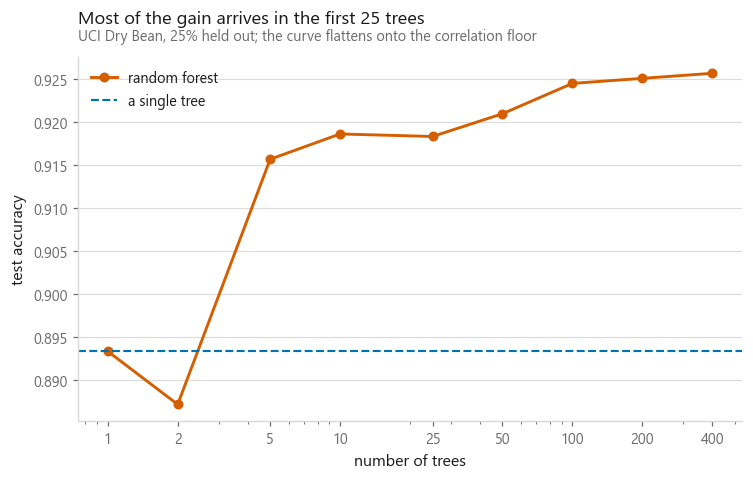

In [3]:
from sklearn.ensemble import RandomForestClassifier

counts = [1, 2, 5, 10, 25, 50, 100, 200, 400]
curve = []
for n in counts:
    model = RandomForestClassifier(n_estimators=n, n_jobs=-1, random_state=SEED)
    model.fit(X_train, y_train)
    curve.append(model.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.plot(counts, curve, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="random forest")
ax.axhline(curve[0], color=style.PALETTE[0], ls="--", lw=1.4, label="a single tree")
ax.set_xscale("log")
ax.set_xticks(counts, [str(c) for c in counts])
ax.set_xlabel("number of trees")
ax.set_ylabel("test accuracy")
ax.legend()
style.title(ax, "Most of the gain arrives in the first 25 trees",
            "UCI Dry Bean, 25% held out; the curve flattens onto the correlation floor")
style.save(fig, FIG / "fig-01-tree-count.png")

print(f"1 tree   : {curve[0]:.4f}")
print(f"25 trees : {curve[4]:.4f}")
print(f"400 trees: {curve[-1]:.4f}")
print(f"gain from 25 -> 400: {curve[-1] - curve[4]:+.4f}")

More trees never make a random forest worse: they only cost time. That is a
genuinely unusual property, and it means `n_estimators` is the one
hyperparameter you can set carelessly. Everything after about 100 is a rounding
error you pay for in seconds.

## 4. In practice

Two conveniences the library gives you and a from-scratch version does not.

**Out-of-bag scoring.** Each tree skipped about 37% of the rows, so those rows
are a ready-made validation set for that tree. Averaging over all trees gives an
honest estimate of held-out accuracy **without any cross-validation at all**.

**No scaling required.** Trees split on thresholds, so multiplying a column by a
thousand changes nothing. There is no `StandardScaler` in this pipeline, and
there does not need to be.

In [4]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)
final = RandomForestClassifier(n_estimators=300, oob_score=True, n_jobs=-1, random_state=SEED)
final.fit(X.values, y.values)

predicted = cross_val_predict(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    X.values, y.values, cv=folds, n_jobs=1)

print(f"out-of-bag accuracy      : {final.oob_score_:.4f}")
print(f"5-fold accuracy          : {accuracy_score(y, predicted):.4f}")
print(f"5-fold balanced accuracy : {balanced_accuracy_score(y, predicted):.4f}")

out-of-bag accuracy      : 0.9248
5-fold accuracy          : 0.9244
5-fold balanced accuracy : 0.9335


The out-of-bag estimate lands within a whisker of the cross-validated one, for a
fraction of the compute. On a large dataset that is a real saving.

### Feature importance, and how it lies

A forest can report which columns it relied on. The default measure is
**impurity decrease**: how much each feature reduced class impurity across all
splits. It is free, and it has a known bias: it inflates high-cardinality and
continuous features, because they offer more places to split.

**Permutation importance** avoids that. Shuffle one column, see how much accuracy
falls, and repeat. Slower, and much harder to fool. Where the two disagree,
believe the second.

                 impurity  permutation  rank gap
roundness          0.0537       0.0836      11.0
ShapeFactor4       0.0311       0.0475      12.0
Perimeter          0.1027       0.0154      -1.0
Solidity           0.0187       0.0077      11.0
Extent             0.0117       0.0062      11.0
ShapeFactor1       0.0874       0.0054      -2.0
Compactness        0.1059       0.0044      -6.0
MajorAxisLength    0.0704       0.0029      -2.0
ShapeFactor3       0.0934       0.0028      -6.0
ConvexArea         0.0688       0.0027      -3.0
MinorAxisLength    0.0749       0.0025      -6.0
EquivDiameter      0.0589       0.0019      -2.0
Area               0.0586       0.0017      -2.0
ShapeFactor2       0.0391       0.0011      -1.0
Eccentricity       0.0641       0.0009      -7.0
AspectRation       0.0606       0.0008      -7.0


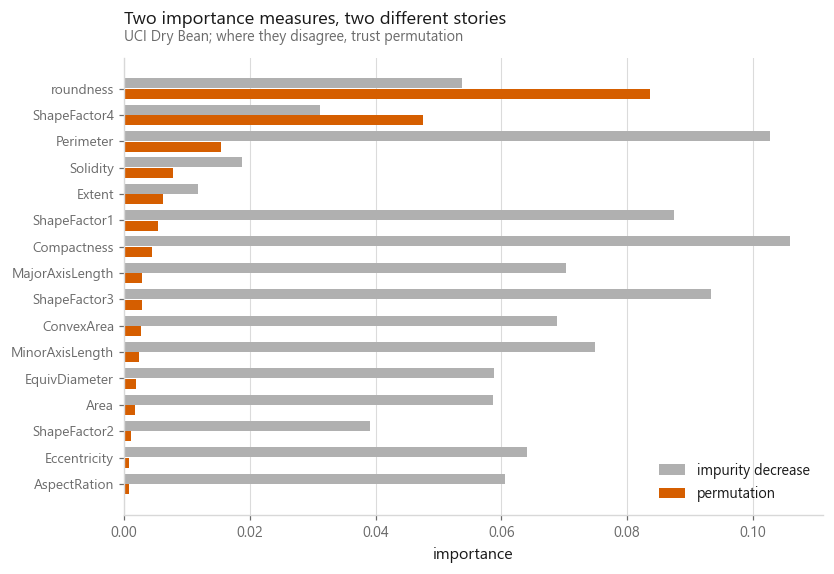

In [5]:
from sklearn.inspection import permutation_importance

impurity = pd.Series(final.feature_importances_, index=X.columns)
perm = permutation_importance(final, X.values, y.values, n_repeats=5,
                              random_state=SEED, n_jobs=-1)
permutation = pd.Series(perm.importances_mean, index=X.columns)

order = permutation.sort_values().index
positions = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.barh(positions + 0.2, impurity[order], height=0.38, color=style.NEUTRAL, label="impurity decrease")
ax.barh(positions - 0.2, permutation[order], height=0.38, color=style.HIGHLIGHT, label="permutation")
ax.set_yticks(positions, order, fontsize=9)
ax.set_xlabel("importance")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
style.title(ax, "Two importance measures, two different stories",
            "UCI Dry Bean; where they disagree, trust permutation")
style.save(fig, FIG / "fig-02-importance.png")

comparison = pd.DataFrame({"impurity": impurity, "permutation": permutation})
comparison["rank gap"] = (comparison.impurity.rank(ascending=False)
                          - comparison.permutation.rank(ascending=False))
print(comparison.sort_values("permutation", ascending=False).round(4).to_string())

## 5. When it wins, when it loses

The direct comparison. Same dataset, same folds, same metric as the
[logistic regression notebook](../../03-classification/01-logistic-regression/).

I built this section expecting the forest to pull clearly ahead of the linear
model. It does not, and the reason is worth more than the win would have been.

                        accuracy  balanced
logistic regression       0.9234    0.9341
one decision tree         0.8945    0.9094
bagging (all features)    0.9245    0.9346
random forest (sqrt)      0.9244    0.9335


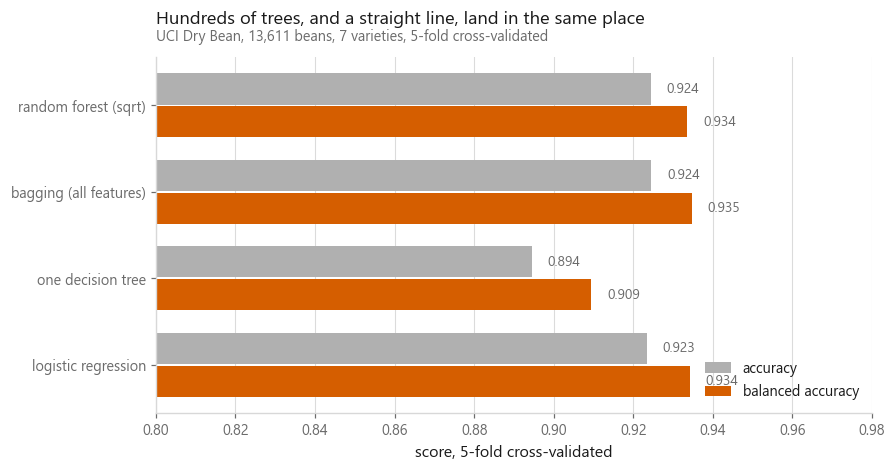

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

contenders = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "one decision tree": DecisionTreeClassifier(random_state=SEED),
    "bagging (all features)": RandomForestClassifier(n_estimators=300, max_features=None,
                                                     n_jobs=-1, random_state=SEED),
    "random forest (sqrt)": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
}

results = {}
for name, estimator in contenders.items():
    guess = cross_val_predict(estimator, X.values, y.values, cv=folds, n_jobs=1)
    results[name] = {"accuracy": accuracy_score(y, guess),
                     "balanced": balanced_accuracy_score(y, guess)}
scores = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(8.4, 4.2))
positions = np.arange(len(scores))
ax.barh(positions + 0.19, scores["accuracy"], height=0.36, color=style.NEUTRAL, label="accuracy")
ax.barh(positions - 0.19, scores["balanced"], height=0.36, color=style.HIGHLIGHT, label="balanced accuracy")
for i, (a, b) in enumerate(zip(scores["accuracy"], scores["balanced"])):
    ax.text(a + 0.004, i + 0.19, f"{a:.3f}", va="center", fontsize=9, color=style.MUTED)
    ax.text(b + 0.004, i - 0.19, f"{b:.3f}", va="center", fontsize=9, color=style.MUTED)
ax.set_yticks(positions, scores.index)
ax.set_xlim(0.80, 0.98)
ax.set_xlabel("score, 5-fold cross-validated")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
style.title(ax, "Hundreds of trees, and a straight line, land in the same place",
            "UCI Dry Bean, 13,611 beans, 7 varieties, 5-fold cross-validated")
style.save(fig, FIG / "fig-03-comparison.png")

print(scores.round(4).to_string())

Read that table carefully, because three things are happening.

**The forest ties with logistic regression.** It gains one thousandth of a point
of accuracy and *loses* on balanced accuracy. For any practical purpose these
are the same model on this data.

**The single tree is the row that matters.** At 0.894 it sits three points below
both. So the ensemble is doing exactly what it promises: it recovers the three
points a lone tree throws away through variance. It just has nothing left over
once it gets there.

**Feature subsampling bought nothing either.** Plain bagging over all 16 features
matched the `sqrt` version. With only 16 columns, and nearly all of them
informative, restricting each split to four costs about as much signal as the
decorrelation gains.

Why does the flexible model not win? The bean features are geometric
measurements of one object: area, perimeter, major and minor axis length,
equivalent diameter. They are smooth, heavily correlated, and the varieties
differ mostly in size and elongation. That is close to the ideal case for a
linear boundary. **There is very little non-linear structure here for a forest
to find**, so its extra expressiveness has nothing to buy.

This is the lesson this book keeps returning to, and it is the answer to "which
algorithm should I use": the more flexible model is not automatically better. It
is better when there is non-linear structure to exploit. Check whether there is
before assuming.

### The boundary, drawn

The logistic regression notebook ended by showing the two most-confused
varieties separated by a straight line cutting through their overlap. Here is
the forest on the identical projection.

most mutually confused pair under the forest: DERMASON and SIRA


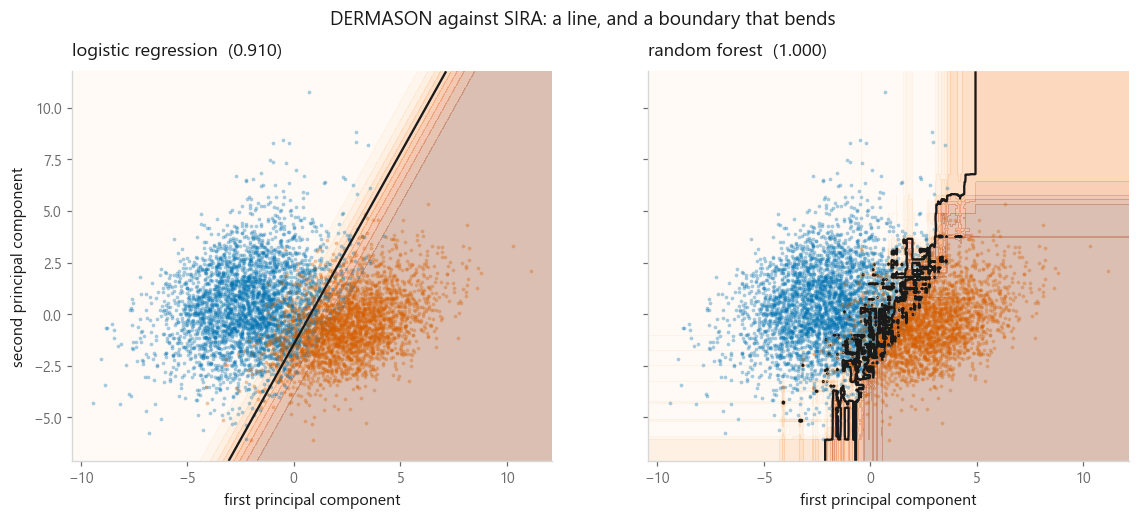

In [7]:
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# Find the same confused pair the logistic regression notebook found, the same
# way: normalise the confusion matrix by true class, add it to its own transpose
# so both directions of confusion count, and take the largest off-diagonal entry.
labels = sorted(y.unique())
matrix = confusion_matrix(y, predicted, labels=labels, normalize="true")
mutual = matrix + matrix.T
np.fill_diagonal(mutual, 0)
i, j = np.unravel_index(np.argmax(mutual), mutual.shape)
pair = [labels[i], labels[j]]
print(f"most mutually confused pair under the forest: {pair[0]} and {pair[1]}")

mask = y.isin(pair).values
X_pair = StandardScaler().fit_transform(X[mask])
y_pair = (y[mask] == pair[1]).astype(int).values
flat = PCA(n_components=2, random_state=SEED).fit_transform(X_pair)

step = 0.03
xx, yy = np.meshgrid(np.arange(flat[:, 0].min() - 1, flat[:, 0].max() + 1, step),
                     np.arange(flat[:, 1].min() - 1, flat[:, 1].max() + 1, step))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), sharex=True, sharey=True)
drawn = {"logistic regression": LogisticRegression(max_iter=3000),
         "random forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)}

for ax, (name, estimator) in zip(axes, drawn.items()):
    estimator.fit(flat, y_pair)
    zz = estimator.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap="Oranges", alpha=0.30)
    ax.contour(xx, yy, zz, levels=[0.5], colors=[style.INK], linewidths=1.5)
    for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
        sel = y_pair == value
        ax.scatter(flat[sel, 0], flat[sel, 1], s=6, alpha=0.35, c=colour, linewidths=0)
    ax.grid(False)
    ax.set_xlabel("first principal component")
    style.title(ax, f"{name}  ({estimator.score(flat, y_pair):.3f})")

axes[0].set_ylabel("second principal component")
fig.suptitle(f"{pair[0]} against {pair[1]}: a line, and a boundary that bends",
             x=0.5, y=1.00, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-boundaries.png")

The forest's boundary bends to follow the seam, and it is visibly rougher, a
staircase of axis-aligned splits rather than a smooth curve. That roughness is
the forest's own failure mode: given depth it will happily carve a pocket around
three stray beans, which is memorising rather than learning. Averaging hundreds
of trees suppresses most of that, though not all of it.

And it barely helps. The bent boundary picks up a fraction of a point over the
straight one, which is the two-dimensional version of the result from the table
above. The seam between these two varieties is genuinely close to straight, so
there is little for the bending to catch.

If you want to see a forest earn its keep, the place to look is a dataset with
real interactions and thresholds rather than smooth geometry. The
[scoreboard](../../12-putting-it-together/01-the-scoreboard/) puts both models
against all five house datasets, and the ordering is not the same everywhere.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Tabular data, mixed feature types, non-linear boundaries, and you want a strong result without tuning |
| **Avoid it when** | You need to extrapolate beyond the training range (trees cannot), you need a tiny model, or the data is images, audio, or text |
| **Scaling needed** | No. Trees split on thresholds; units are irrelevant |
| **Main dials** | `n_estimators` (more is never worse), `max_features` (the real lever), `max_depth` and `min_samples_leaf` to restrain overfitting |
| **Free extras** | `oob_score=True` gives a validation estimate with no extra fitting |
| **Watch out** | Default feature importance inflates continuous and high-cardinality columns. Use permutation importance to check |
| **Next** | [Gradient boosting](../05-gradient-boosting/), which usually edges it out on tabular data at the cost of needing to be tuned |

## What to remember

1. Trees have low bias and high variance. A forest averages the variance away
   and keeps the low bias.
2. Averaging is floored by how correlated the trees are, which is why bootstrap
   sampling and feature subsampling exist.
3. More trees never hurt accuracy. Only your patience.
4. Out-of-bag scoring is a free validation set.
5. No scaling required, ever.
6. Treat default feature importance with suspicion; permutation importance is
   slower and far more honest.
7. On this dataset the forest tied with logistic regression. A flexible model
   only wins where there is non-linear structure to win with, and smooth
   geometric measurements do not offer much.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-05 Gradient boosting](../05-gradient-boosting/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#RandomForest` `#Ensemble` `#Bagging` `#DecisionTrees`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#FeatureImportance`